##🧬High-Throughput GC Content Analysis Framework for FASTA Datasets

This Python script **performs comparative GC content analysis on multiple FASTA files and visualizes the results using a bar chart**. It is designed for bioinformatics applications where genomic composition needs to be evaluated across different gene sequences or datasets.

The program extracts gene names and sequence information from processed FASTA results, calculates GC content percentages, and generates a visual comparison using Matplotlib. Each gene is represented as a labeled bar, making it easy to identify variations in GC content across samples.

Additionally, the script saves the generated visualization as a high-resolution PNG file and enables automatic download for further reporting or presentation use.

## Key Features:

Processes multiple FASTA file results
Extracts gene names and GC content values
Generates a clear bar chart for comparison
Saves plot as a downloadable image (PNG)
Useful for genomic analysis and bioinformatics reporting

## Libraries Used:

matplotlib.pyplot – for data visualization
google.colab.files – for file download (Colab environment)

## Output:
A bar chart image (gc_content_plot.png) showing GC content (%) comparison across selected gene sequences.

In [1]:
from google.colab import files

In [9]:
from google.colab import files
import csv   # ✅ FIX 1: missing import

# -----------------------------
# Upload FASTA file
# -----------------------------
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# -----------------------------
# FASTA parser
# -----------------------------
def parse_fasta(file_name):
    sequences = {}
    header = ""
    seq = ""

    with open(file_name, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if header:
                    sequences[header] = seq
                header = line[1:]
                seq = ""
            else:
                seq += line

        if header:
            sequences[header] = seq

    return sequences

# -----------------------------
# GC content function
# -----------------------------
def gc_content(seq):
    return round((seq.count("G") + seq.count("C")) / len(seq) * 100, 2)

# -----------------------------
# Load data
# -----------------------------
data = parse_fasta(file_name)

# -----------------------------
# Collect results (FIXED STRUCTURE)
# -----------------------------
results = []   # ✅ FIX 2: define proper structure

all_outputs = []

for gene, seq in data.items():
    gc = gc_content(seq)
    length = len(seq)

    # For text report
    result_text = (
        f"Gene: {gene}\n"
        f"Length: {length}\n"
        f"GC Content: {gc}%\n"
        f"{'-'*30}\n"
    )

    all_outputs.append(result_text)

    # For CSV
    results.append([file_name, gene, length, gc])

# -----------------------------
# FINAL OUTPUT
# -----------------------------
print("\n🧬 FINAL GC CONTENT REPORT")
print("=" * 50)
print("\n".join(all_outputs))
print("=" * 50)
print("Analysis Completed Successfully ✅")

# -----------------------------
# Save CSV
# -----------------------------
csv_file = "multi_fasta_gc_report.csv"

with open(csv_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["File_Name", "Gene", "Length", "GC_Content"])
    writer.writerows(results)

# -----------------------------
# Save TXT
# -----------------------------
txt_file = "gc_report.txt"

with open(txt_file, "w") as f:
    f.write("🧬 GC CONTENT ANALYSIS REPORT\n")
    f.write("=" * 50 + "\n\n")
    f.write("\n".join(all_outputs))
    f.write("\nAnalysis Completed Successfully ✅")

# -----------------------------
# Download files
# -----------------------------
files.download(csv_file)
files.download(txt_file)

Saving Human TP53 gene seqdump.txt to Human TP53 gene seqdump.txt

🧬 FINAL GC CONTENT REPORT
Gene: NM_000546.6 Homo sapiens tumor protein p53 (TP53), transcript variant 1, mRNA
Length: 2512
GC Content: 53.38%
------------------------------

Gene: HG975427.1 TPA: Homo sapiens Processed transcript p53-mRNA (p53 gene)
Length: 2586
GC Content: 53.36%
------------------------------

Gene: NM_001276761.3 Homo sapiens tumor protein p53 (TP53), transcript variant 2, mRNA
Length: 2509
GC Content: 53.37%
------------------------------

Gene: AF307851.1 Homo sapiens p53 protein mRNA, complete cds
Length: 2521
GC Content: 53.23%
------------------------------

Gene: XM_001172077.6 PREDICTED: Pan troglodytes tumor protein p53 (TP53), transcript variant X2, mRNA
Length: 2537
GC Content: 53.02%
------------------------------

Gene: XM_004058511.5 PREDICTED: Gorilla gorilla gorilla tumor protein p53 (TP53), transcript variant X2, mRNA
Length: 2529
GC Content: 53.14%
------------------------------

Gen

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
results.append([file_name, gene, len(seq), gc])

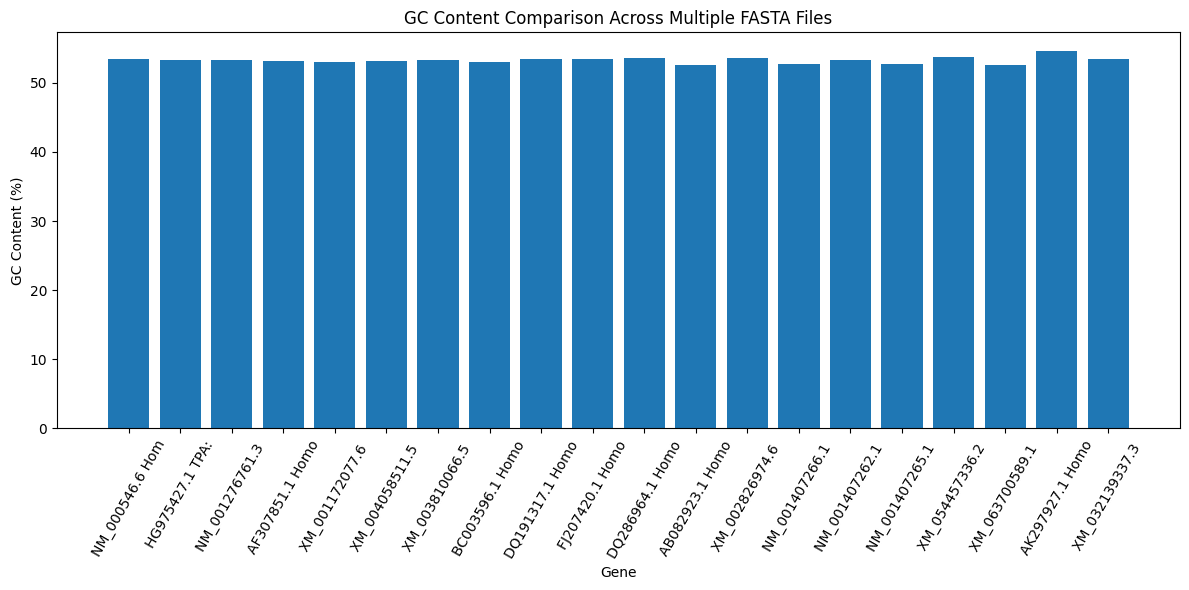

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import matplotlib.pyplot as plt
from google.colab import files

# Prepare labels and values
labels = [row[1][:15] for row in results]   # gene names (shortened)
gc_values = [row[3] for row in results]     # GC content

# Create bar chart
plt.figure(figsize=(12,6))
plt.bar(labels, gc_values)

plt.xlabel("Gene")
plt.ylabel("GC Content (%)")
plt.title("GC Content Comparison Across Multiple FASTA Files")

plt.xticks(rotation=60)
plt.tight_layout()

# Save the plot as PNG
file_path = "gc_content_plot.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")

plt.show()

# Download to your system (Colab)
files.download(file_path)

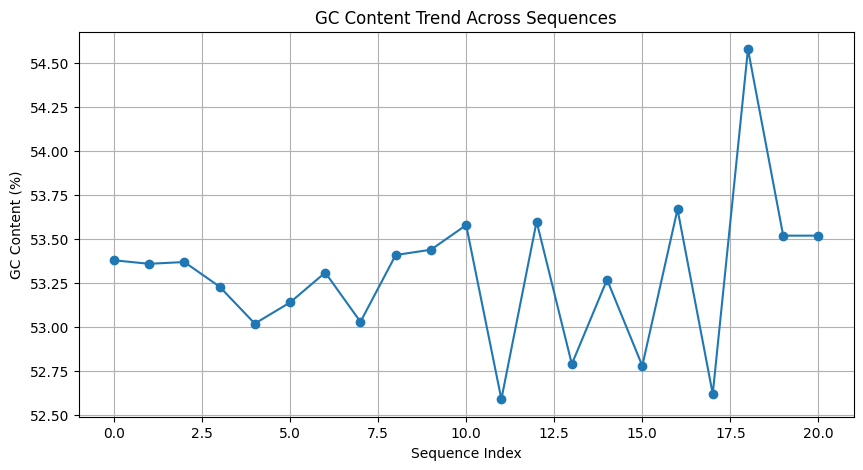

In [12]:
import matplotlib.pyplot as plt

# Extract values
gc_values = [row[3] for row in results]

plt.figure(figsize=(10,5))
plt.plot(gc_values, marker='o')

plt.xlabel("Sequence Index")
plt.ylabel("GC Content (%)")
plt.title("GC Content Trend Across Sequences")

plt.grid(True)
plt.show()

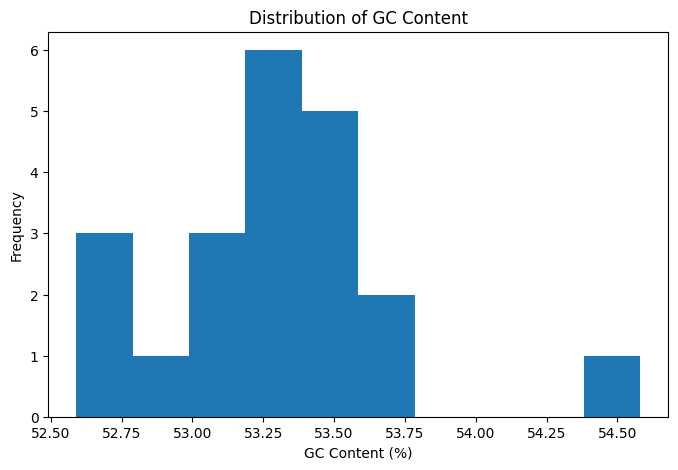

In [13]:
import matplotlib.pyplot as plt

gc_values = [row[3] for row in results]

plt.figure(figsize=(8,5))
plt.hist(gc_values, bins=10)

plt.xlabel("GC Content (%)")
plt.ylabel("Frequency")
plt.title("Distribution of GC Content")

plt.show()

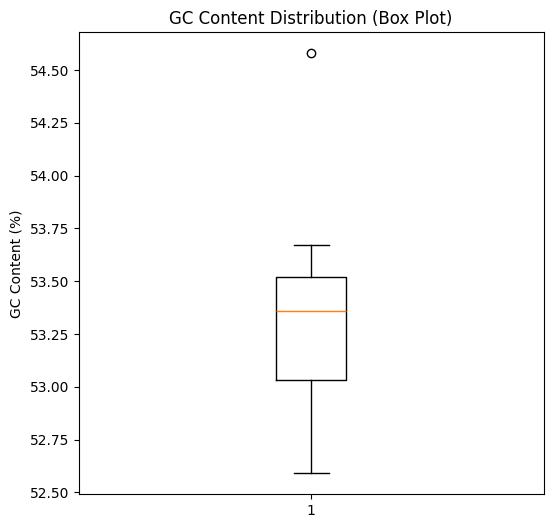

In [14]:
import matplotlib.pyplot as plt

# Extract GC values
gc_values = [row[3] for row in results]

plt.figure(figsize=(6,6))
plt.boxplot(gc_values)

plt.ylabel("GC Content (%)")
plt.title("GC Content Distribution (Box Plot)")

plt.show()

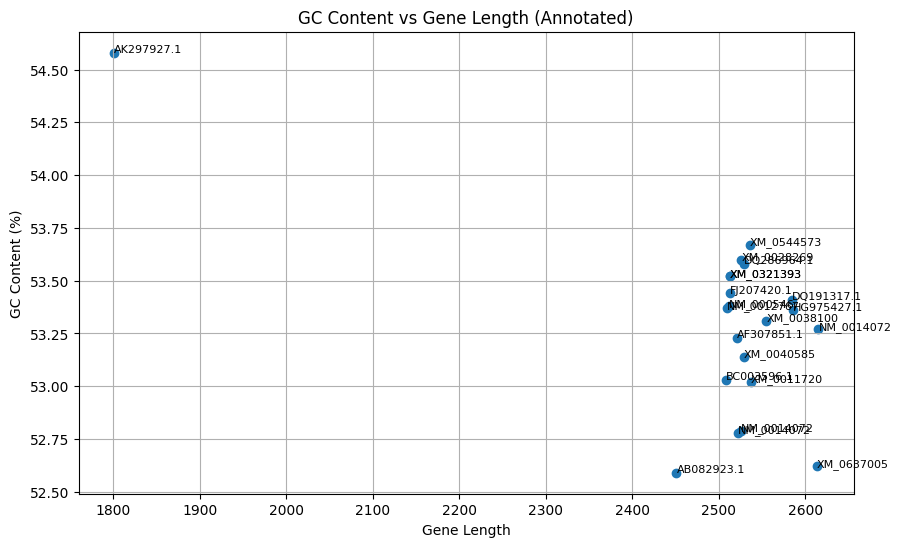

In [15]:
import matplotlib.pyplot as plt

lengths = [row[2] for row in results]
gc_values = [row[3] for row in results]
labels = [row[1][:10] for row in results]  # short gene names

plt.figure(figsize=(10,6))
plt.scatter(lengths, gc_values)

# annotate points (optional but powerful)
for i, label in enumerate(labels):
    plt.text(lengths[i], gc_values[i], label, fontsize=8)

plt.xlabel("Gene Length")
plt.ylabel("GC Content (%)")
plt.title("GC Content vs Gene Length (Annotated)")

plt.grid(True)
plt.show()

In [16]:
mean_gc = sum(gc_values) / len(gc_values)

print(f"📊 Average GC Content: {round(mean_gc,2)}%")

if mean_gc > 60:
    print("📌 Overall dataset is GC-rich")
elif mean_gc < 40:
    print("📌 Overall dataset is AT-rich")
else:
    print("📌 Balanced GC distribution")

📊 Average GC Content: 53.3%
📌 Balanced GC distribution


In [17]:
import numpy as np

correlation = np.corrcoef(lengths, gc_values)[0,1]

print(f"📊 Correlation between GC content and gene length: {round(correlation, 3)}")

if correlation > 0.5:
    print("📌 Strong positive correlation")
elif correlation < -0.5:
    print("📌 Strong negative correlation")
else:
    print("📌 Weak or no correlation")

📊 Correlation between GC content and gene length: -0.651
📌 Strong negative correlation


In [18]:
print("📌 Observation:")
print("Variation in GC content reflects genomic differences across organisms/genes.")

📌 Observation:
Variation in GC content reflects genomic differences across organisms/genes.


In [19]:
pip install streamlit matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 77.1 MB/s eta 0:00:00


In [21]:
# ==============================
# AUTO REPORT GENERATOR (FIXED)
# ==============================

# ✅ Auto-install (important for Colab)
try:
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
except:
    !pip install reportlab
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image

from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import letter
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# -----------------------------
# SAFETY CHECK: results exists
# -----------------------------
if 'results' not in globals() or len(results) == 0:
    raise ValueError("❌ 'results' list is empty. Run your GC analysis first.")

# -----------------------------
# Extract Data
# -----------------------------
lengths = [row[2] for row in results]
gc_values = [row[3] for row in results]

# -----------------------------
# 1. SCATTER PLOT
# -----------------------------
plt.figure()
plt.scatter(lengths, gc_values)
plt.xlabel("Gene Length")
plt.ylabel("GC Content (%)")
plt.title("GC Content vs Gene Length")

scatter_path = "scatter.png"
plt.savefig(scatter_path)
plt.close()

# -----------------------------
# 2. HISTOGRAM
# -----------------------------
plt.figure()
plt.hist(gc_values, bins=10)
plt.xlabel("GC Content (%)")
plt.ylabel("Frequency")
plt.title("GC Content Distribution")

hist_path = "hist.png"
plt.savefig(hist_path)
plt.close()

# -----------------------------
# 3. BOX PLOT
# -----------------------------
plt.figure()
plt.boxplot(gc_values)
plt.ylabel("GC Content (%)")
plt.title("GC Content Box Plot")

box_path = "box.png"
plt.savefig(box_path)
plt.close()

# -----------------------------
# 4. ANALYSIS
# -----------------------------
mean_gc = round(np.mean(gc_values), 2)

if mean_gc > 60:
    interpretation = "The dataset is GC-rich, indicating stable genomic regions."
elif mean_gc < 40:
    interpretation = "The dataset is AT-rich, suggesting flexible genomic regions."
else:
    interpretation = "The dataset shows balanced GC content."

# -----------------------------
# 5. CREATE PDF
# -----------------------------
doc = SimpleDocTemplate("GC_Content_Report.pdf", pagesize=letter)
styles = getSampleStyleSheet()

content = []

# Title
content.append(Paragraph("GC Content Analysis Report", styles['Title']))
content.append(Spacer(1, 12))

# Abstract
content.append(Paragraph(
    "This report presents GC content analysis of DNA sequences from FASTA files. "
    "Statistical visualization techniques were applied to interpret GC variation.",
    styles['BodyText']
))
content.append(Spacer(1, 12))

# Results
content.append(Paragraph(f"Average GC Content: {mean_gc}%", styles['Heading2']))
content.append(Paragraph(interpretation, styles['BodyText']))
content.append(Spacer(1, 12))

# Figures
content.append(Paragraph("GC Content vs Gene Length", styles['Heading2']))
content.append(Image(scatter_path, width=400, height=300))
content.append(Spacer(1, 12))

content.append(Paragraph("GC Content Distribution", styles['Heading2']))
content.append(Image(hist_path, width=400, height=300))
content.append(Spacer(1, 12))

content.append(Paragraph("GC Content Box Plot", styles['Heading2']))
content.append(Image(box_path, width=400, height=300))
content.append(Spacer(1, 12))

# Conclusion
content.append(Paragraph(
    "The variation in GC content suggests differences in genomic stability and gene structure. "
    "Further analysis may reveal functional implications.",
    styles['BodyText']
))

# Build PDF
doc.build(content)

# -----------------------------
# 6. DOWNLOAD
# -----------------------------
files.download("GC_Content_Report.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
from google.colab import files

# List of all output files
output_files = [
    "scatter.png",
    "hist.png",
    "box.png",
    "GC_Content_Report.pdf"
]

# Download each file
for file in output_files:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

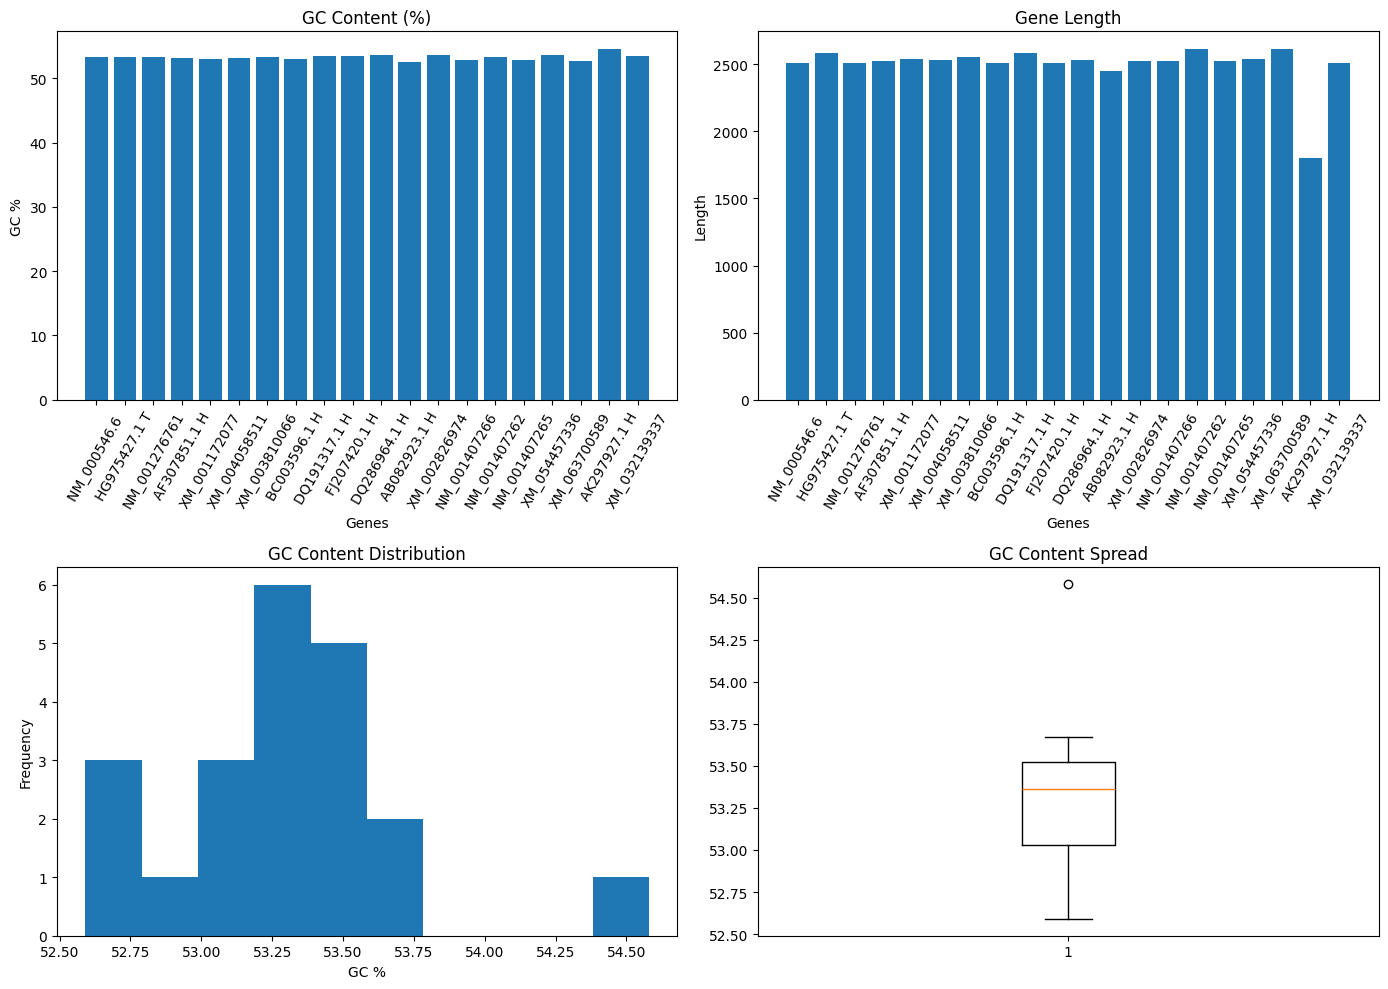

Dashboard saved as gc_dashboard.png ✅


In [30]:
import matplotlib.pyplot as plt
import csv

# -----------------------------
# Assume results = [file, gene, length, gc]
# -----------------------------
# Example format:
# results = [["file1", "geneA", 100, 52.3], ...]

labels = [row[1][:12] for row in results]
gc_values = [row[3] for row in results]
length_values = [row[2] for row in results]

# -----------------------------
# Create FULL dashboard figure
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -----------------------------
# Plot 1: GC Content Bar Chart
# -----------------------------
axes[0, 0].bar(labels, gc_values)
axes[0, 0].set_title("GC Content (%)")
axes[0, 0].set_xlabel("Genes")
axes[0, 0].set_ylabel("GC %")
axes[0, 0].tick_params(axis='x', rotation=60)

# -----------------------------
# Plot 2: Gene Length Bar Chart
# -----------------------------
axes[0, 1].bar(labels, length_values)
axes[0, 1].set_title("Gene Length")
axes[0, 1].set_xlabel("Genes")
axes[0, 1].set_ylabel("Length")
axes[0, 1].tick_params(axis='x', rotation=60)

# -----------------------------
# Plot 3: GC Distribution Histogram
# -----------------------------
axes[1, 0].hist(gc_values, bins=10)
axes[1, 0].set_title("GC Content Distribution")
axes[1, 0].set_xlabel("GC %")
axes[1, 0].set_ylabel("Frequency")

# -----------------------------
# Plot 4: Box Plot (GC Spread)
# -----------------------------
axes[1, 1].boxplot(gc_values)
axes[1, 1].set_title("GC Content Spread")

# -----------------------------
# Final layout fix
# -----------------------------
plt.tight_layout()

# -----------------------------
# SAVE as PNG
# -----------------------------
output_file = "gc_dashboard.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight")

plt.show()

print("Dashboard saved as gc_dashboard.png ✅")